In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from lib.ECP import Agent, ErgodicCP

In [12]:
# Change to True if you cannot run the program using high specs
low_performance_mode = True

In [13]:
kappa_true = 10
kappa_est = np.random.uniform(1, 100)

lambda_buy = 0.4
lambda_sell = 0.4
q_upper, q_lower = 30, -30
phi = 1e-6

simga = 0.01

T = 50 if low_performance_mode else 100
dt=1
K_upper=100
delta0=1e-8

ts = np.linspace(0, T, int(T/dt)+1)
print(ts.size)
no_of_ts = ts.size  - 1

Regret_MC = 10 if low_performance_mode else 100
regret_samples = 2 if low_performance_mode else 5

51


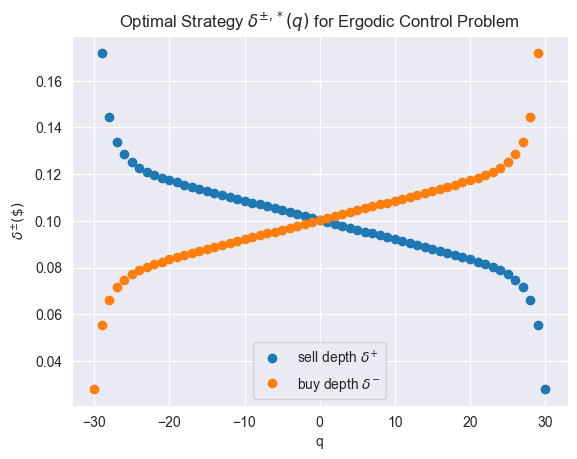

In [14]:
ErgodicCP(
    lambda_buy=lambda_buy,
    lambda_sell=lambda_sell,
    q_upper=q_upper,
    q_lower=q_lower,
    phi=phi,
    kappa=kappa_true,
).plot_EControl

In [15]:
MC_regret = []
MC_kappa = []


for _ in range(Regret_MC):
    regret_list = []
    kappa_list = []
    for _ in range(regret_samples):
        kappa_est = np.random.uniform(50, 100)

        agent = Agent(
            lambda_buy=lambda_buy,
            lambda_sell=lambda_sell,
            q_upper=q_upper,
            q_lower=q_lower,
            phi=phi,
            kappa_est=kappa_est,
            T=T,
            dt=dt,
            K_upper=K_upper,
            delta0=delta0, 
        )

        agent.learning(sigma=simga, kappa_true=kappa_true)

        kappa_list.append(agent.kappa_learnlist)
        regret_list.append(agent.regret(kappa_true=kappa_true))

    kappa_list = np.array(kappa_list)
    regret_list = np.array(regret_list)
    MC_regret.append(np.mean(regret_list, axis=0))
    MC_kappa.append(np.mean(kappa_list, axis=0))

MC_kappa = np.array(MC_kappa)
MC_regret = np.array(MC_regret)

In [17]:
df_kappa = pd.DataFrame(MC_kappa)
df_regret = pd.DataFrame(MC_regret)

df_kappa.to_csv("file_kappa_t" + str(no_of_ts) + ".csv", header=False, index=False)
df_regret.to_csv("file_regret_t" + str(no_of_ts) + ".csv", header=False, index=False)

MC_kappa = pd.read_csv("file_kappa_t" + str(no_of_ts) + ".csv", header=None, index_col=None)
MC_regret = pd.read_csv("file_regret_t" + str(no_of_ts) + ".csv", header=None, index_col=None)

MC_kappa = np.array(MC_kappa)
MC_regret = np.array(MC_regret)

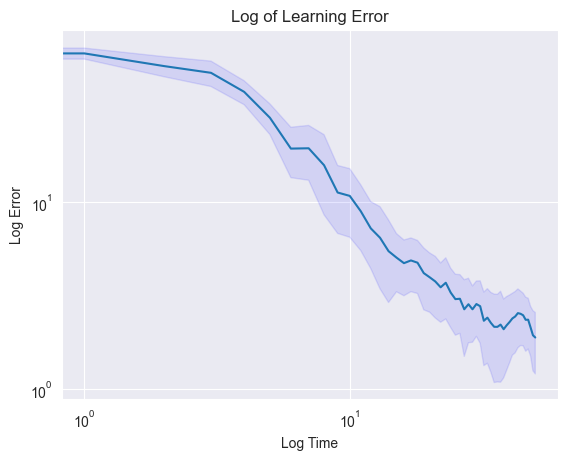

In [18]:
std = np.std(MC_kappa-kappa_true, axis=0)
ci = 1.64 * std/np.sqrt(Regret_MC)
y = np.mean(MC_kappa, axis=0)-kappa_true

fig, ax = plt.subplots()
ax.loglog(ts, y)
ax.fill_between(ts, (y-ci), (y+ci), color='b', alpha=.1)

# plt.loglog(ts[1:], ts[1:]**(-0.5), '--')
plt.xlabel("Log Time")
plt.ylabel("Log Error")
plt.title("Log of Learning Error")
plt.show()

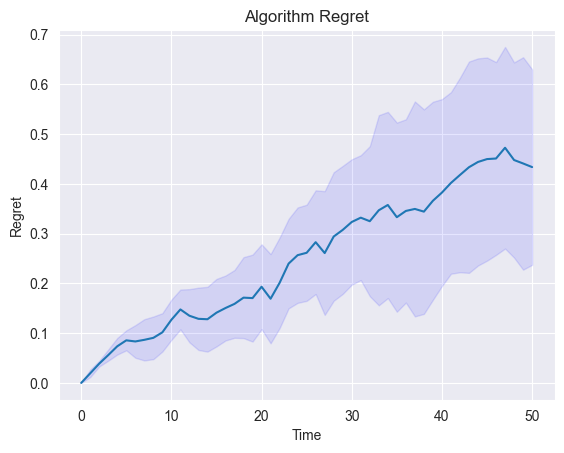

In [19]:
std = np.std(MC_regret, axis=0)
ci = 1.96 * std/np.sqrt(Regret_MC)
y = np.mean(MC_regret, axis=0)

fig, ax = plt.subplots()
ax.plot(ts, y)
ax.fill_between(ts, (y-ci), (y+ci), color='b', alpha=.1)
plt.xlabel("Time")
plt.ylabel("Regret")
plt.title("Algorithm Regret")
plt.show()

In [20]:
start = 10

y_axis = (y)[start:]
y_axis_upper = (y+ci)[start:]
x_axis = ts[start:]

# Define the quadratic model
def log_square_model(x, c, m):
    return c * (np.log(x)**2) + m

def calculate_r2(data, fit_data):
    residual = data - fit_data
    ss_res = np.sum(residual**2)
    ss_tot = np.sum((data - np.mean(data))**2)
    r_2 = 1 - ss_res / ss_tot
    return r_2

def log_model(x,c, m):
    return c * np.log(x) + m

# Use log^2 model
params, covariance = curve_fit(log_square_model, x_axis, y_axis)
c_estimated = params[0]
m_estimated = params[1]

params_upper, covariance_upper = curve_fit(log_square_model, x_axis, y_axis_upper)
c_estimated_upper = params_upper[0]
m_estimated_upper = params_upper[1]



# Use log model 
params_log, covariance_log = curve_fit(log_model, x_axis, y_axis)
c_estimated_log = params_log[0]
m_estimated_log = params_log[1]


params_upper_log, covariance_upper_log = curve_fit(log_model, x_axis, y_axis_upper)
c_estimated_upper_log = params_upper_log[0]
m_estimated_upper_log = params_upper_log[1]

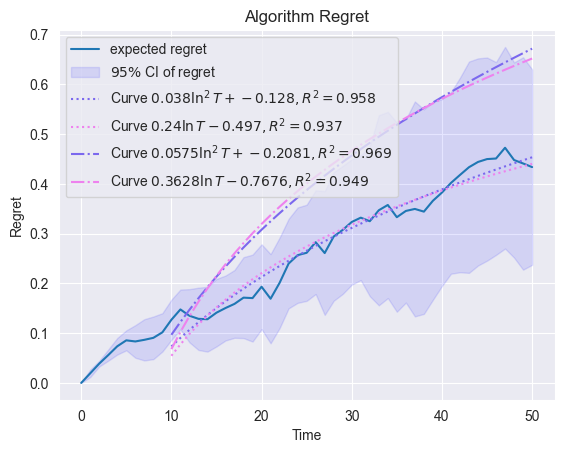

In [21]:
fig, ax = plt.subplots()
ax.plot(ts, y, label='expected regret')
ax.fill_between(ts, (y-ci), (y+ci), color='b', alpha=.1, label='$95\%$ CI of regret')

x_fit = ts[start:]
y_fit = log_square_model(x_fit, c_estimated, m_estimated)
y_fit_upper = log_square_model(x_fit, c_estimated_upper, m_estimated_upper)

y_fit_log = log_model(x_fit, c_estimated_log, m_estimated_log)
y_fit_upper_log = log_model(x_fit, c_estimated_upper_log, m_estimated_upper_log)

ax.plot(x_fit, y_fit, color='mediumslateblue',linestyle=':', label=f'Curve ${np.round(c_estimated, 3)} \ln^2 T + {np.round(m_estimated,4)}, R^2 = {np.round(calculate_r2(y_axis, y_fit),3)}$')
ax.plot(x_fit, y_fit_log, color='violet',linestyle=':', label=f'Curve ${np.round(c_estimated_log, 3)} \ln T   {np.round(m_estimated_log,4)}, R^2 = {np.round(calculate_r2(y_axis, y_fit_log),3)}$')


ax.plot(x_fit, y_fit_upper, color='mediumslateblue',linestyle='dashdot', label=f'Curve ${np.round(c_estimated_upper, 4)} \ln^2 T + {np.round(m_estimated_upper,4)},  R^2 = {np.round(calculate_r2(y_axis_upper, y_fit_upper),3)}$')
ax.plot(x_fit, y_fit_upper_log, color='violet',linestyle='dashdot', label=f'Curve ${np.round(c_estimated_upper_log, 4)} \ln T {np.round(m_estimated_upper_log,4)}, R^2 = {np.round(calculate_r2(y_axis_upper, y_fit_upper_log),3)}$')

plt.xlabel("Time")
plt.ylabel("Regret")
plt.title("Algorithm Regret")
plt.legend()
plt.show()

In [22]:
#Ignore below here for now

MC_kappa_long = pd.read_csv("kappa_new.csv", header=None, index_col=None)
MC_regret_long = pd.read_csv("regret_new.csv", header=None, index_col=None)

MC_kappa_long = np.array(MC_kappa_long)
MC_regret_long = np.array(MC_regret_long)

FileNotFoundError: [Errno 2] No such file or directory: 'kappa_new.csv'

In [ ]:
T_long=1000
dt=1

ts_long = np.linspace(0, T_long, int(T_long/dt)+1)

std_kappa_long = np.std(MC_kappa_long-kappa_true, axis=0)
ci_kappa_long = 1.64 * std_kappa_long/np.sqrt(Regret_MC)

fig, ax = plt.subplots()
ax.loglog(ts_long, np.mean(MC_kappa_long, axis=0)-kappa_true)
ax.fill_between(ts_long, (np.mean(MC_kappa_long, axis=0)-kappa_true-ci_kappa_long), (np.mean(MC_kappa_long, axis=0)-kappa_true+ci_kappa_long), color='b', alpha=.1)

# plt.loglog(ts[1:], ts[1:]**(-0.5), '--')
plt.xlabel("Log Time")
plt.ylabel("Log Error")
plt.title("Log of Learning Error")
plt.show()

In [ ]:
std_regret_long = np.std(MC_regret_long, axis=0)
ci_regret_long = 1.96 * std_regret_long/np.sqrt(Regret_MC)

fig, ax = plt.subplots()
ax.plot(ts_long, np.mean(MC_regret_long, axis=0))
ax.fill_between(ts_long, (np.mean(MC_regret_long, axis=0)-ci_regret_long), (np.mean(MC_regret_long, axis=0)+ci_regret_long), color='b', alpha=.1)
plt.xlabel("Time")
plt.ylabel("Regret")
plt.title("Algorithm Regret")
plt.show()

In [ ]:
start = 2


y_axis = (y)[start:]
y_axis_upper = (y+ci)[start:]
x_axis = ts[start:]

# Define the quadratic model
def log_square_model(x, c, m):
    return c * (np.log(x)**2) + m

def calculate_r2(data, fit_data):
    residual = data - fit_data
    ss_res = np.sum(residual**2)
    ss_tot = np.sum((data - np.mean(data))**2)
    r_2 = 1 - ss_res / ss_tot
    return r_2

def log_model(x,c, m):
    return c * np.log(x) + m

# Use log^2 model
params, covariance = curve_fit(log_square_model, x_axis, y_axis)
c_estimated = params[0]
m_estimated = params[1]

params_upper, covariance_upper = curve_fit(log_square_model, x_axis, y_axis_upper)
c_estimated_upper = params_upper[0]
m_estimated_upper = params_upper[1]



# Use log model 
params_log, covariance_log = curve_fit(log_model, x_axis, y_axis)
c_estimated_log = params_log[0]
m_estimated_log = params_log[1]


params_upper_log, covariance_upper_log = curve_fit(log_model, x_axis, y_axis_upper)
c_estimated_upper_log = params_upper_log[0]
m_estimated_upper_log = params_upper_log[1]

In [ ]:
fig, ax = plt.subplots()
ax.plot(ts, y, label='expected regret')
ax.fill_between(ts, (y-ci), (y+ci), color='b', alpha=.1, label='$95\%$ CI of regret')

x_fit = ts[start:]
y_fit = log_square_model(x_fit, c_estimated, m_estimated)
y_fit_upper = log_square_model(x_fit, c_estimated_upper, m_estimated_upper)

y_fit_log = log_model(x_fit, c_estimated_log, m_estimated_log)
y_fit_upper_log = log_model(x_fit, c_estimated_upper_log, m_estimated_upper_log)

ax.plot(x_fit, y_fit, color='mediumslateblue',linestyle=':', label=f'Curve ${np.round(c_estimated, 3)} \ln^2 T + {np.round(m_estimated,4)}, R^2 = {np.round(calculate_r2(y_axis, y_fit),3)}$')
ax.plot(x_fit, y_fit_log, color='violet',linestyle=':', label=f'Curve ${np.round(c_estimated_log, 3)} \ln T   {np.round(m_estimated_log,4)}, R^2 = {np.round(calculate_r2(y_axis, y_fit_log),3)}$')


ax.plot(x_fit, y_fit_upper, color='mediumslateblue',linestyle='dashdot', label=f'Curve ${np.round(c_estimated_upper, 4)} \ln^2 T + {np.round(m_estimated_upper,4)},  R^2 = {np.round(calculate_r2(y_axis_upper, y_fit_upper),3)}$')
ax.plot(x_fit, y_fit_upper_log, color='violet',linestyle='dashdot', label=f'Curve ${np.round(c_estimated_upper_log, 4)} \ln T {np.round(m_estimated_upper_log,4)}, R^2 = {np.round(calculate_r2(y_axis_upper, y_fit_upper_log),3)}$')

plt.xlabel("Time")
plt.ylabel("Regret")
plt.title("Algorithm Regret")
plt.legend()
plt.show()

In [ ]:
# --- Shared models ---
def log_square_model(x, c, m):
    return c * (np.log(x) ** 2) + m

def log_model(x, c, m):
    return c * np.log(x) + m

def calculate_r2(data, fit_data):
    residual = data - fit_data
    ss_res = np.sum(residual ** 2)
    ss_tot = np.sum((data - np.mean(data)) ** 2)
    return 1 - ss_res / ss_tot

# ---- Data preparation ----
# Plot 1: Log-log learning error
std_kappa = np.std(MC_kappa - kappa_true, axis=0)
ci_kappa = 1.64 * std_kappa / np.sqrt(Regret_MC)
y_kappa = np.mean(MC_kappa, axis=0) - kappa_true

# Plot 2: Regret with curve fits
std_regret = np.std(MC_regret, axis=0)
ci_regret = 1.96 * std_regret / np.sqrt(Regret_MC)
y_regret = np.mean(MC_regret, axis=0)
start = 10
x_fit = ts[start:]
y_fit = y_regret[start:]
y_fit_upper = (y_regret + ci_regret)[start:]

params, _ = curve_fit(log_square_model, x_fit, y_fit)
params_upper, _ = curve_fit(log_square_model, x_fit, y_fit_upper)
params_log, _ = curve_fit(log_model, x_fit, y_fit)
params_log_upper, _ = curve_fit(log_model, x_fit, y_fit_upper)

# Plot 3: Log-log learning error (long horizon)
std_kappa_long = np.std(MC_kappa_long - kappa_true, axis=0)
ci_kappa_long = 1.64 * std_kappa_long / np.sqrt(Regret_MC)
y_kappa_long = np.mean(MC_kappa_long, axis=0) - kappa_true

# Plot 4: Regret long horizon with curve fits
std_regret_long = np.std(MC_regret_long, axis=0)
ci_regret_long = 1.96 * std_regret_long / np.sqrt(Regret_MC)
y_regret_long = np.mean(MC_regret_long, axis=0)
start_long = 2
x_fit_long = ts_long[start_long:]
y_fit_long = y_regret_long[start_long:]
y_fit_long_upper = (y_regret_long + ci_regret_long)[start_long:]

params_long, _ = curve_fit(log_square_model, x_fit_long, y_fit_long)
params_long_upper, _ = curve_fit(log_square_model, x_fit_long, y_fit_long_upper)
params_log_long, _ = curve_fit(log_model, x_fit_long, y_fit_long)
params_log_long_upper, _ = curve_fit(log_model, x_fit_long, y_fit_long_upper)

# ---- Plotting ----
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

# Subplot 1: Log Learning Error
axs[0, 0].loglog(ts, y_kappa)
axs[0, 0].fill_between(ts, y_kappa - ci_kappa, y_kappa + ci_kappa, color='b', alpha=0.1)
axs[0, 0].set_title("Log of learning error of $\kappa$")
axs[0, 0].set_xlabel("Log Time (s)")
axs[0, 0].set_ylabel("Log Error")

# Subplot 2: Algorithm Regret with Curve Fits
axs[0, 1].plot(ts, y_regret, label='expected regret')
axs[0, 1].fill_between(ts, y_regret - ci_regret, y_regret + ci_regret, color='b', alpha=0.1, label='$95\\%$ CI of regret')
axs[0, 1].plot(x_fit, log_square_model(x_fit, *params), color='mediumslateblue', linestyle=':', 
    label=fr'Curve ${params[0]:.3f} \ln^2 T + {params[1]:.4f}, R^2 = {calculate_r2(y_fit, log_square_model(x_fit, *params)):.3f}$')
axs[0, 1].plot(x_fit, log_model(x_fit, *params_log), color='violet', linestyle=':', 
    label=fr'Curve ${params_log[0]:.3f} \ln T   {params_log[1]:.4f}, R^2 = {calculate_r2(y_fit, log_model(x_fit, *params_log)):.3f}$')
axs[0, 1].plot(x_fit, log_square_model(x_fit, *params_upper), color='mediumslateblue', linestyle='dashdot',
    label=fr'Curve ${params_upper[0]:.4f} \ln^2 T + {params_upper[1]:.4f},  R^2 = {calculate_r2(y_fit_upper, log_square_model(x_fit, *params_upper)):.3f}$')
axs[0, 1].plot(x_fit, log_model(x_fit, *params_log_upper), color='violet', linestyle='dashdot',
    label=fr'Curve ${params_log_upper[0]:.4f} \ln T {params_log_upper[1]:.4f}, R^2 = {calculate_r2(y_fit_upper, log_model(x_fit, *params_log_upper)):.3f}$')
axs[0, 1].set_title("Algorithm regret")
axs[0, 1].set_xlabel("Time (s)")
axs[0, 1].set_ylabel("Regret (\$)")
axs[0, 1].legend(fontsize=8)

# Subplot 3: Log Learning Error (long)
axs[1, 0].loglog(ts_long, y_kappa_long)
axs[1, 0].fill_between(ts_long, y_kappa_long - ci_kappa_long, y_kappa_long + ci_kappa_long, color='b', alpha=0.1)
axs[1, 0].set_title("Log of learning error of $\kappa$ (Longer time horizon)")
axs[1, 0].set_xlabel("Log Time (s)")
axs[1, 0].set_ylabel("Log Error")

# Subplot 4: Algorithm Regret (Long Horizon)
axs[1, 1].plot(ts_long, y_regret_long, label='expected regret')
axs[1, 1].fill_between(ts_long, y_regret_long - ci_regret_long, y_regret_long + ci_regret_long, color='b', alpha=0.1, label='$95\\%$ CI of regret')
axs[1, 1].plot(x_fit_long, log_square_model(x_fit_long, *params_long), color='mediumslateblue', linestyle=':',
    label=fr'Curve ${params_long[0]:.3f} \ln^2 T + {params_long[1]:.4f}, R^2 = {calculate_r2(y_fit_long, log_square_model(x_fit_long, *params_long)):.3f}$')
axs[1, 1].plot(x_fit_long, log_model(x_fit_long, *params_log_long), color='violet', linestyle=':',
    label=fr'Curve ${params_log_long[0]:.3f} \ln T   {params_log_long[1]:.4f}, R^2 = {calculate_r2(y_fit_long, log_model(x_fit_long, *params_log_long)):.3f}$')
axs[1, 1].plot(x_fit_long, log_square_model(x_fit_long, *params_long_upper), color='mediumslateblue', linestyle='dashdot',
    label=fr'Curve ${params_long_upper[0]:.4f} \ln^2 T + {params_long_upper[1]:.4f},  R^2 = {calculate_r2(y_fit_long_upper, log_square_model(x_fit_long, *params_long_upper)):.3f}$')
axs[1, 1].plot(x_fit_long, log_model(x_fit_long, *params_log_long_upper), color='violet', linestyle='dashdot',
    label=fr'Curve ${params_log_long_upper[0]:.4f} \ln T {params_log_long_upper[1]:.4f}, R^2 = {calculate_r2(y_fit_long_upper, log_model(x_fit_long, *params_log_long_upper)):.3f}$')
axs[1, 1].set_title("Algorithm regret (Longer time horizon)")
axs[1, 1].set_xlabel("Time (s)")
axs[1, 1].set_ylabel("Regret (\$)")
axs[1, 1].legend(fontsize=8)

plt.tight_layout()


plt.show()
plt.close()
